# Wprowadzenie

W ramach tego laboratorium celem jest zapoznanie się z podstawami uczenia nienadzorowanego, w zadaniu klasteryzacji danych. Zadanie klasteryzacji polega na odkryciu naturalnych struktur w zbiorze danych poprzez ich grupowanie na podstawie podobieństwa.

W laboratorium analizowane są dwie popularne metody klasteryzacji:
- **K-means** – algorytm dzielący dane na *k* grup o minimalnym rozproszeniu wewnętrznym. Wymaga wcześniejszego określenia liczby klastrów,
- **DBSCAN** – algorytm wykrywający skupiska punktów o wysokiej gęstości. Nie wymaga podania liczby klastrów i automatycznie wykrywa szum.

W eksperymentach przetestowano różne konfiguracje obu algorytmów na zbiorach danych: **IRIS**, **SEEDS** oraz **GLASS**. Do oceny jakości uzyskanych klastrów zastosowano zarówno metryki niezależne od etykiet klas (takie jak **Silhouette Score**, **Davies-Bouldin Index**), jak i metryki wykorzystujące znane etykiety (**Adjusted Rand Index**, **Purity Score**).

Dodatkowo przeprowadzono wizualizację wyników oraz porównanie skuteczności obu algorytmów i zastosowanych miar jakości.

# Imports

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from copy import deepcopy
from ucimlrepo import fetch_ucirepo 
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# 1. Sanity check

## 1.1 Wczytanie danych

In [70]:
iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target
scaler = StandardScaler()
X_iris = scaler.fit_transform(X_iris)

## 1.2 wczytanie i uruchomienie k-means na IRIS

In [81]:
kmeans = KMeans(n_clusters=3, n_init=10)
kmeans.fit(X_iris)
y_kmeans = kmeans.predict(X_iris)
kmeans.cluster_centers_

array([[-0.05021989, -0.88337647,  0.34773781,  0.2815273 ],
       [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
       [ 1.13597027,  0.08842168,  0.99615451,  1.01752612]])

## 1.3 Wizualizacje

Algorytm KMeans dla domyślnych parametrów utworzył 3 klastry, co odpowiada liczbie klas w zbiorze danych IRIS. Wykresy pokazują, że algorytm przeciętnie oddzielił różne gatunki irysów na podstawie ich cech. 
Warto zauważyć, że niektóre punkty danych są blisko siebie, co może sugerować, że niektóre gatunki są trudne do odróżnienia na podstawie tych cech.

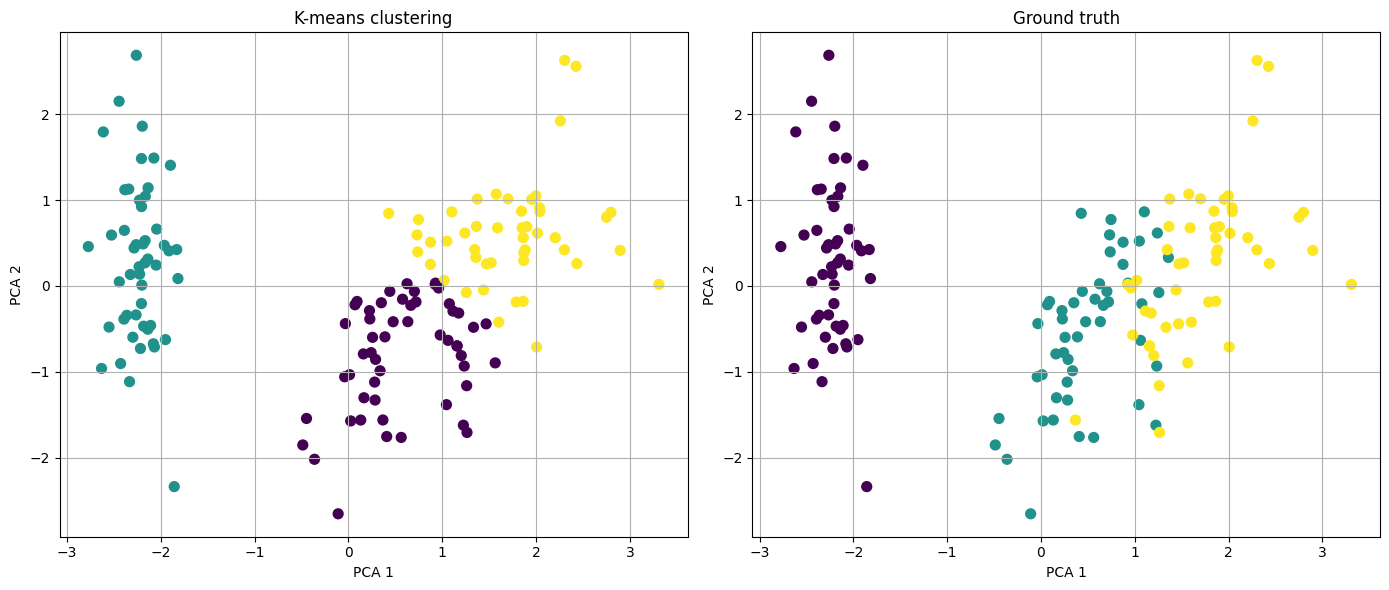

In [82]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50)
axes[0].set_title('K-means clustering')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].grid(True)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis', s=50)
axes[1].set_title('Ground truth')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 1.4 Obliczenie metryk jakości

### 1. Silhouette Score
- **Zakres wartości:** od **-1** do **1**
- **Interpretacja:** wyższa wartość oznacza lepsze dopasowanie obiektów do własnych klastrów (dobrze oddzielone klastry)
- **Opis:** Mierzy, jak podobny dany punkt jest do punktów w swoim klastrze w porównaniu do punktów w innych klastrach. Wartość bliska 1 oznacza dobrze dopasowany punkt; bliska 0 oznacza, że punkt znajduje się na granicy klastrów; wartości ujemne sugerują błędne przypisanie.


### 2. Davies-Bouldin Index
- **Zakres wartości:** od **0** do ∞
- **Interpretacja:** niższa wartość oznacza lepsze grupowanie
- **Opis:** Oblicza stosunek odległości między klastrami do ich "rozmycia" (wewnętrznej spójności). Niższe wartości oznaczają lepsze rozdzielenie i bardziej zwarte klastry.


### 3. Adjusted Rand Index
- **Zakres wartości:** od **-1** do **1**
- **Interpretacja:** im wyżej, tym lepsze dopasowanie do etykiet referencyjnych (idealnie bliska 1)
- **Opis:** Mierzy podobieństwo między dwoma przypisaniami (np. etykiety rzeczywiste vs. predykcje), korygując losowe dopasowanie. Wartość 1 oznacza idealne dopasowanie, 0 to wynik losowy, a wartości ujemne oznaczają gorsze niż losowe dopasowanie.


### 4. Purity Score
- **Zakres wartości:** od **0** do **1**
- **Interpretacja:** wyższa wartość oznacza lepsze dopasowanie do klas rzeczywistych
- **Opis:** Dla każdego klastra przypisuje najbardziej dominującą klasę prawdziwą i sprawdza, jaka część przypisanych próbek do klastrów jest poprawna. Prosty, intuicyjny wskaźnik jakości klasteryzacji w kontekście znanych etykiet.


### 1.4.1 Obliczenie metryk bez GT

Silhouette Score: 0.460 – wskazuje na umiarkowanie dobrą separację między klastrami; struktura klastrów jest wyraźna, ale nie idealna.

Davies-Bouldin Index: 0.834 – stosunkowo niski, co sugeruje, że klastry są dobrze rozdzielone i zwarte (niższe wartości są lepsze).

In [6]:
silhouette = silhouette_score(X_iris, y_kmeans)
davies_bouldin = davies_bouldin_score(X_iris, y_kmeans)

print(f'Silhouette Score: {silhouette:.3f}')
print(f'Davies-Bouldin Index: {davies_bouldin:.3f}')

Silhouette Score: 0.460
Davies-Bouldin Index: 0.834


### 1.4.2 Obliczenie metryk z GT

Purity Score: 0.833 – wysoka zgodność klastrów z rzeczywistymi etykietami klas, choć nie jest to wynik idealny.

Adjusted Rand Index: 0.620 – umiarkowanie wysoka zgodność klasteryzacji z rzeczywistym podziałem na klasy; wynik sugeruje, że algorytm poprawnie uchwycił wiele struktur klasowych.

In [7]:
def purity_score(y_true, y_pred):
    contingency = confusion_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)

purity = purity_score(y_iris, y_kmeans)
print(f'Purity Score: {purity:.3f}')

ari = adjusted_rand_score(y_iris, y_kmeans)
print(f'Adjusted Rand Index: {ari:.3f}')

Purity Score: 0.833
Adjusted Rand Index: 0.620


# 2. Przebadanie algorytmu k-means na zbiorach SEEDS i GLASS. Zbadanie jak zmieniają się wartości miar

### Parametry algorytmu k-means

- **n_clusters** - Liczba klastrów do utworzenia. Musi być dodatnia. Określa liczbę centroidów.

- **init** 
  Metoda inicjalizacji centroidów:
  - `'k-means++'` – domyślna, wybiera początkowe klastry w sposób zoptymalizowany,
  - `'random'` – losowa inicjalizacja,
  - `ndarray` – ręcznie podane początkowe pozycje centroidów.

- **n_init** - Liczba niezależnych uruchomień algorytmu z różnymi początkowymi centroidami. Wynik z najmniejszą sumą kwadratów błędów zostaje wybrany.

- **max_iter** - Maksymalna liczba iteracji jednego uruchomienia algorytmu k-średnich.

- **tol** - Tolerancja względnej zmiany w inercji. Jeśli zmiana między iteracjami jest mniejsza niż `tol`, algorytm przerywa działanie.


## 2.1 GLASS

### 2.1.1 Wczytanie danych

In [8]:
glass_identification = fetch_ucirepo(id=42) 
  
X_glass = glass_identification.data.features 
y_glass = glass_identification.data.targets 
y_glass = y_glass.values.ravel()

scaler = StandardScaler()
X_glass = scaler.fit_transform(X_glass)

### 2.1.2 Uruchomienie k-means dla różnych hiperparametrów

In [9]:
supervised_metrics_names = ['silhouette', 'davies_bouldin', 'purity', 'ari']
supervised_metrics_functions = [silhouette_score, davies_bouldin_score, purity_score, adjusted_rand_score]

Wybrano zdywersyfikowane wartości k, aby zobaczyć, jak zmienia się jakość klasteryzacji w zależności od liczby klastrów. Wartości k: 3, 5 (za mało klastrów), 7 (idealna liczba, więc wyklonano więcej eksperymentów dla różnych wartości max_iter oraz n_init), 9 (za dużo klastrów)

In [10]:
glass_kmeans_hyperparams = [
    {'n_3__m_300__init_10' :{'n_clusters': 3, 'max_iter': 300, 'n_init': 10}},
    {'n_5__m_300__init_10' :{'n_clusters': 5, 'max_iter': 300, 'n_init': 10}},
    {'n_9__m_300__init_10' :{'n_clusters': 9, 'max_iter': 300, 'n_init': 10}},
    {'n_7__m_300__init_10' :{'n_clusters': 7, 'max_iter': 300, 'n_init': 10}},
    {'n_7__m_100__init_3' :{'n_clusters': 7, 'max_iter': 100, 'n_init': 3}},
    {'n_7__m_500__init_20' :{'n_clusters': 7, 'max_iter': 500, 'n_init': 20}},
    {'n_7__m_300__init_3' :{'n_clusters': 7, 'max_iter': 300, 'n_init': 3}},
]

In [11]:
def build_metrics(hyperparams_sets, metrics_names):
    """
    Builds metrics dict for experiment.
    Dictionary contains experiment name as key and dictionary as value.
    The inner dictionary keys are metric names, the values are an empty lists for each metrics values
    example:
    {'n_3__m_300__init_10': 
        {'silhouette': [],
        'davies_bouldin': [],
        'purity': [],
        'ari': []
        },
    }
    """
    metrics = {}
    for hyperparam_set in hyperparams_sets:
        for name in hyperparam_set.keys():
            metrics[name] = {}
            for metric_name in metrics_names:
                metrics[name][metric_name] = []
    
    return metrics

In [12]:
def train_kmeans(X, y, hyperparams_sets, metrics_names, metrics_functions):
    """
    Trains KMeans model with different hyperparameters and calculates metrics.
    The function takes a list of hyperparameters and a list of metrics names and functions.
    It returns a dictionary with experiment names as keys and dictionaries as values.
    """
    metrics = build_metrics(hyperparams_sets, metrics_names)
    for experiment in hyperparams_sets:
        experiment_name = list(experiment.keys())[0]
        hyperparams = experiment[experiment_name]

        for _ in range(5):
            kmeans = KMeans(n_clusters=hyperparams['n_clusters'], max_iter=hyperparams['max_iter'], n_init=hyperparams['n_init'])
            kmeans.fit(X)
            y_kmeans = kmeans.predict(X)

            for metric_name, metrics_function in zip(metrics_names, metrics_functions):
                if metric_name in ['purity', 'ari']:
                    metrics[experiment_name][metric_name].append(metrics_function(y, y_kmeans))
                else:
                    metrics[experiment_name][metric_name].append(metrics_function(X, y_kmeans))

    return metrics

In [13]:
glass_kmeans_results = train_kmeans(X_glass, y_glass, glass_kmeans_hyperparams, supervised_metrics_names, supervised_metrics_functions)

### 2.1.3 Obliczenie metryk jakości

In [14]:
def plot_results_kmeans(results, metrics_names):
    data = []
    for experiment_name, metrics_dict in results.items():
        for metric_name, values in metrics_dict.items():
            for value in values:
                data.append({
                    'experiment': experiment_name,
                    'metric': metric_name,
                    'value': float(value)
                })

    df_metrics = pd.DataFrame(data)

    plt.figure(figsize=(16, 10))
    for i, metric_name in enumerate(metrics_names):
        plt.subplot(2, 2, i + 1)
        sns.boxplot(data=df_metrics[df_metrics['metric'] == metric_name],
                    x='experiment', y='value')
        plt.title(f'Metric: {metric_name}', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Experiment')
        plt.ylabel('Score')
        plt.grid(True)

    plt.tight_layout()
    plt.suptitle('KMeans Clustering Metrics Across Experiments', fontsize=16, y=1.03)
    plt.show()


#### Metryki niezależne od etykiet:
- **Najlepszy Silhouette Score**: `n_3__m_300__init_10` – dobra separacja 3 klastrów.
- **Najlepszy Davies-Bouldin Index** (niższy = lepszy): `n_7__m_100__init_3` – zwarte i dobrze oddzielone klastry.

#### Metryki zależne od etykiet:
- **Najlepszy Purity Score**: `n_9__m_300__init_10` oraz `n_7__m_300__init_10`.
- **Najlepszy Adjusted Rand Index (ARI)**: `n_5__m_300__init_10` – najlepsze odwzorowanie prawdziwych klas.

#### Najgorsze wyniki:
- **Najgorszy Silhouette Score**: `n_7__m_100__init_3`.
- **Najgorszy Davies-Bouldin Index**: `n_3__m_300__init_10`.
- **Najgorszy Purity i ARI**: `n_3__m_300__init_10` – mimo dobrej struktury klastrów, słaba zgodność z etykietami klas.


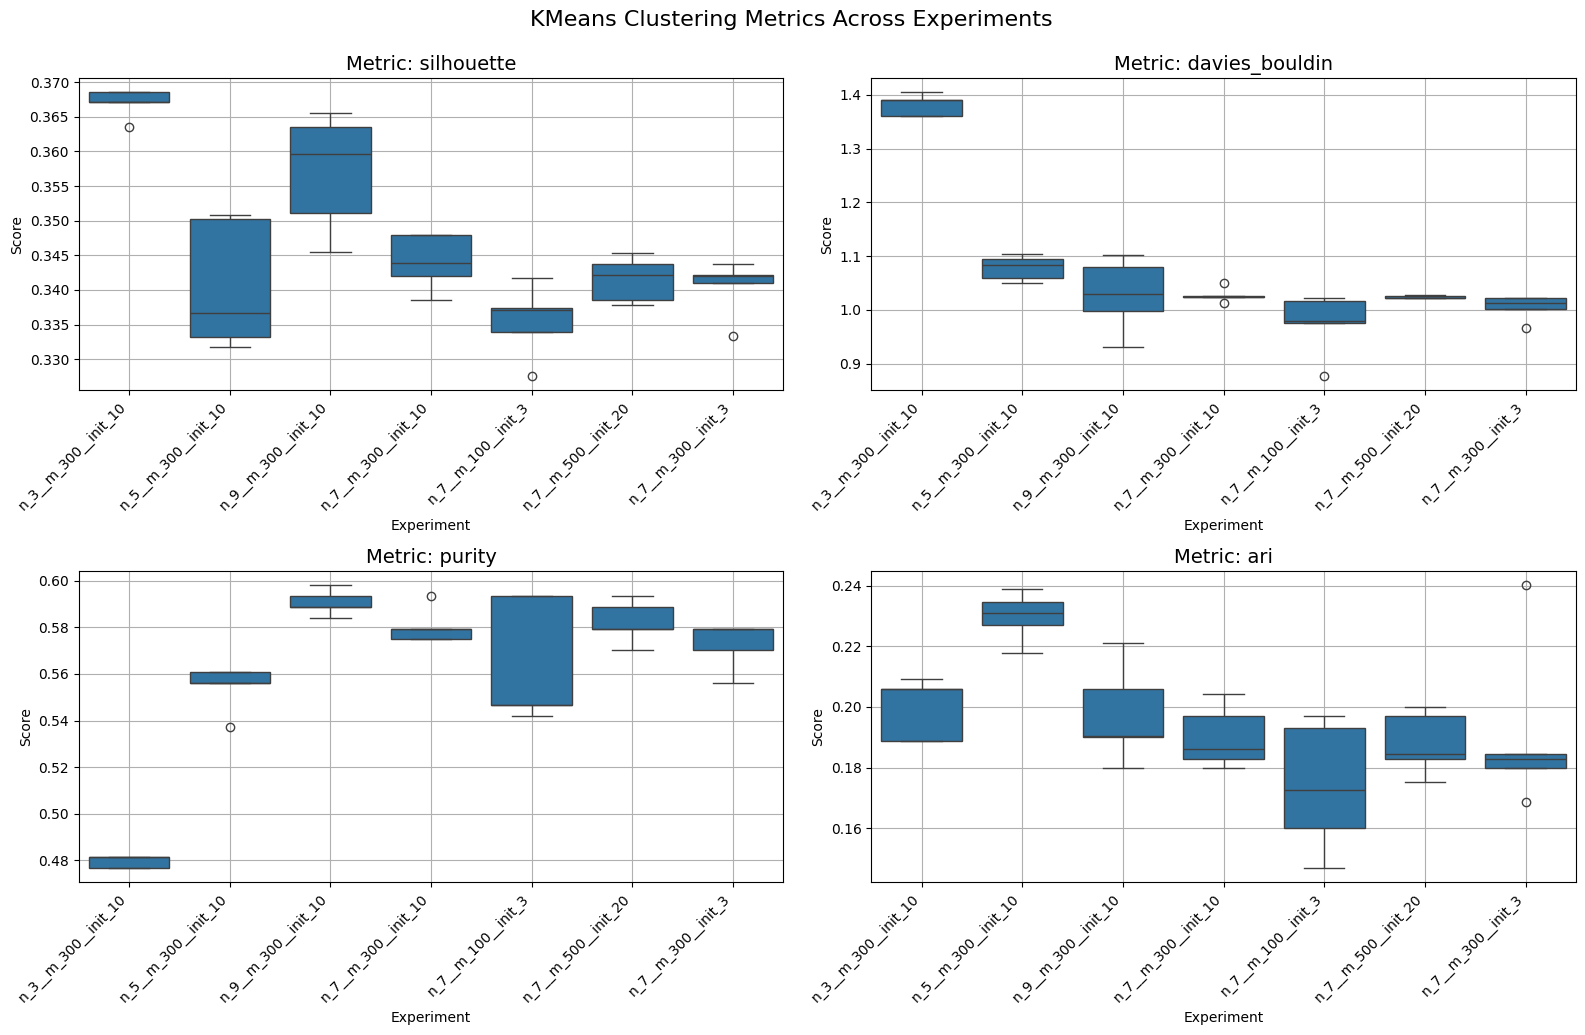

In [15]:
plot_results_kmeans(glass_kmeans_results, supervised_metrics_names)

### 2.1.4 Wizualizacje

In [16]:
kmeans = KMeans(n_clusters=7, max_iter=500, n_init=20)
kmeans.fit(X_glass)
glass_y_kmeans_n7_m500_i20 = kmeans.predict(X_glass)

kmeans = KMeans(n_clusters=3, max_iter=300, n_init=10)
kmeans.fit(X_glass)
glass_y_kmeans_n3_m300_i10 = kmeans.predict(X_glass)

kmeans = KMeans(n_clusters=9, max_iter=300, n_init=10)
kmeans.fit(X_glass)
glass_y_kmeans_n9_m300_i10 = kmeans.predict(X_glass)

In [17]:
def plot_clusters(X, y, experiments, dim_red_method):
    if dim_red_method == 'PCA':
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(X)
    else:
        tsne = TSNE(n_components=2, perplexity=50)
        reduced = tsne.fit_transform(X)

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    axes[0][0].scatter(reduced[:, 0], reduced[:, 1], c=experiments[0][0], cmap='viridis', s=50)
    axes[0][0].set_title(experiments[0][1])
    axes[0][0].set_xlabel('PCA 1')
    axes[0][0].set_ylabel('PCA 2')
    axes[0][0].grid(True)

    axes[0][1].scatter(reduced[:, 0], reduced[:, 1], c=experiments[1][0], cmap='viridis', s=50)
    axes[0][1].set_title(experiments[1][1])
    axes[0][1].set_xlabel('PCA 1')
    axes[0][1].set_ylabel('PCA 2')
    axes[0][1].grid(True)

    axes[1][0].scatter(reduced[:, 0], reduced[:, 1], c=experiments[2][0], cmap='viridis', s=50)
    axes[1][0].set_title(experiments[2][1])
    axes[1][0].set_xlabel('PCA 1')
    axes[1][0].set_ylabel('PCA 2')
    axes[1][0].grid(True)

    axes[1][1].scatter(reduced[:, 0], reduced[:, 1], c=y, cmap='viridis', s=50)
    axes[1][1].set_title('Ground truth')
    axes[1][1].set_xlabel('PCA 1')
    axes[1][1].set_ylabel('PCA 2')
    axes[1][1].grid(True)

    plt.suptitle(f'Clusters with {dim_red_method}', fontsize=16)

    plt.tight_layout()
    plt.show()


Analiza wizualizacji jest bardzo trudna do zinterpretowania ze względu na bardzo bliskie rozłożenie punktów. 

Widać, że niektóre klastry są dobrze oddzielone, ale inne są blisko siebie.

Najlepsze wyniki uzyskano dla 7 klastrów, co sugeruje, że dane mają naturalną strukturę z 7 grupami.

O dziwo równie dobre wyniki utrzymał algorytm dla 9 klastrów, co może sugerować, że algorytm k-means nie jest w stanie dobrze oddzielić klastry, które są blisko siebie.

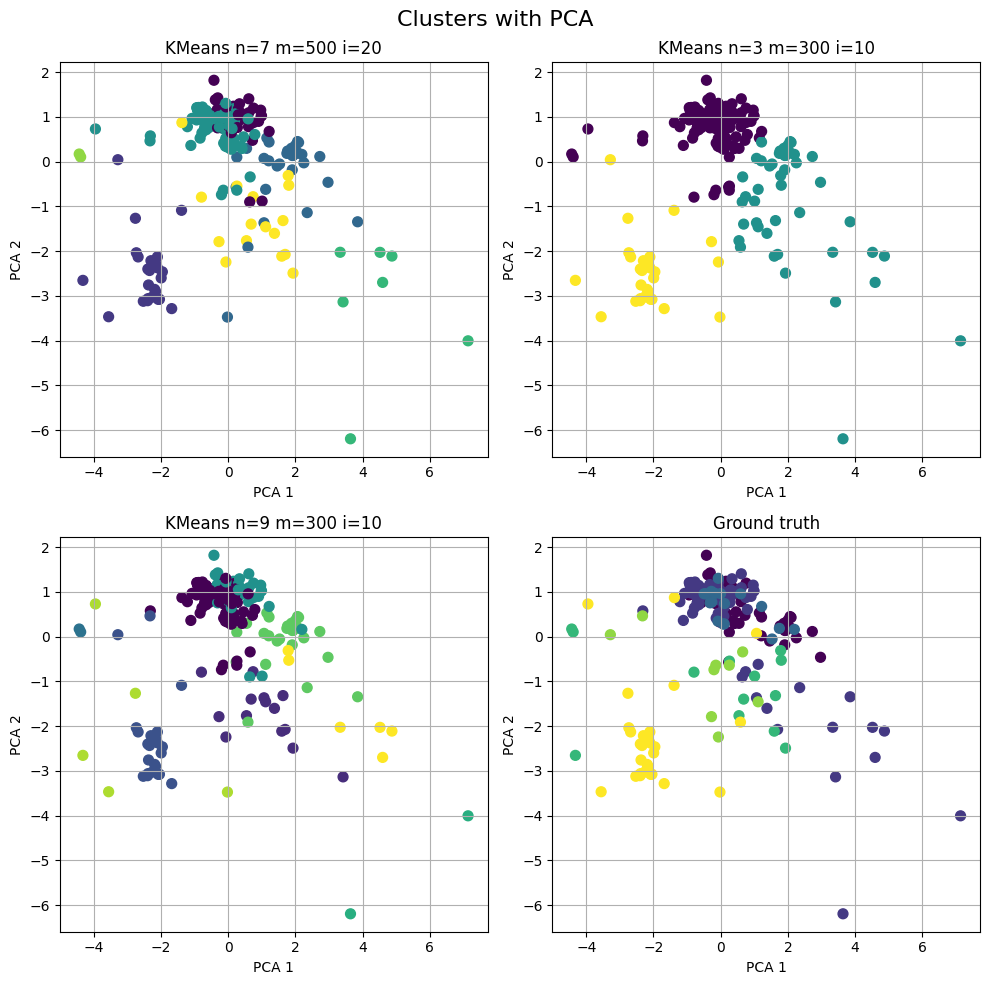

In [18]:
plot_clusters(X_glass, y_glass, [(glass_y_kmeans_n7_m500_i20, 'KMeans n=7 m=500 i=20'),
                                 (glass_y_kmeans_n3_m300_i10, 'KMeans n=3 m=300 i=10'),
                                 (glass_y_kmeans_n9_m300_i10, 'KMeans n=9 m=300 i=10')],
              dim_red_method='PCA')

Dla wizualizacji TSNE można zaobserwować przerwaę w jakości klasteryzacji algorytmu dla 9 klastrów.

Wyniki dla 7 klastrów są minimalnie gorsze, ponieważ utrworzyły duży klaster w centrum generalizując aż 3 klasy.

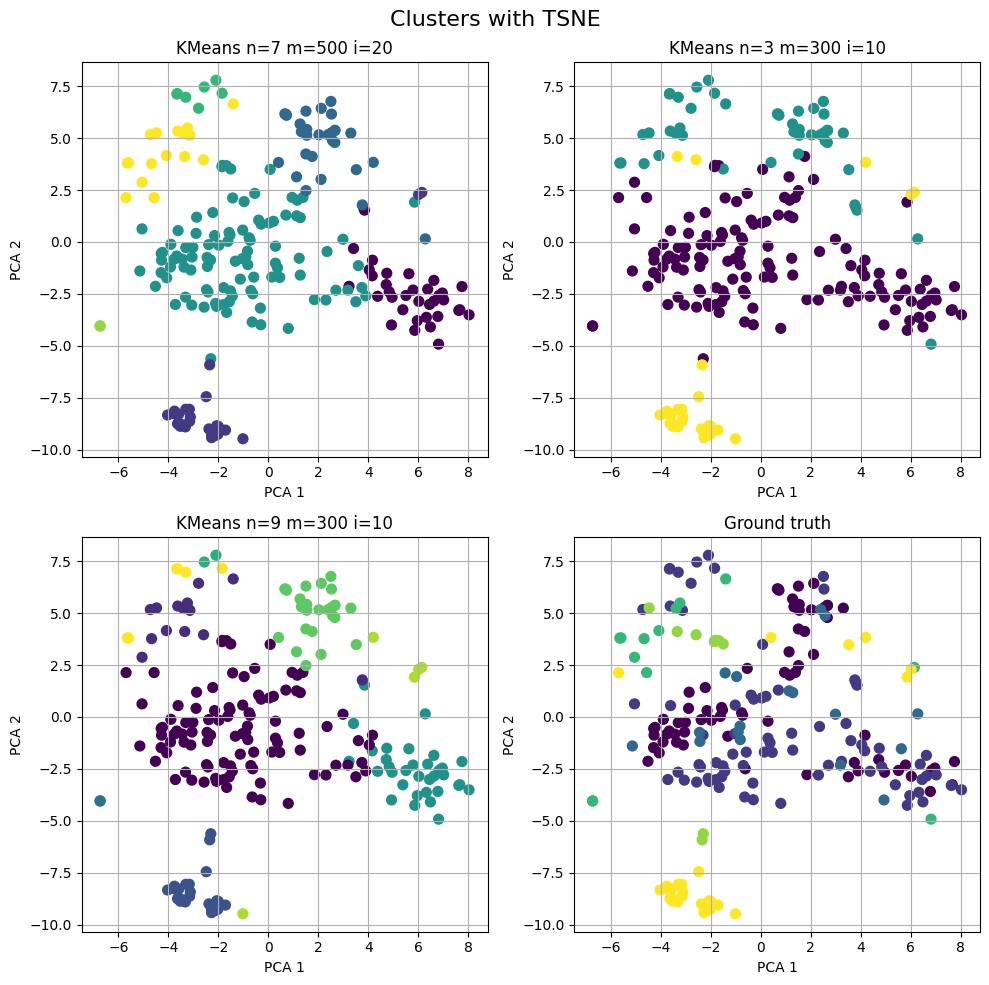

In [19]:
plot_clusters(X_glass, y_glass, [(glass_y_kmeans_n7_m500_i20, 'KMeans n=7 m=500 i=20'),
                                 (glass_y_kmeans_n3_m300_i10, 'KMeans n=3 m=300 i=10'),
                                 (glass_y_kmeans_n9_m300_i10, 'KMeans n=9 m=300 i=10')],
              dim_red_method='TSNE')

## 2.2 SEEDS

### 2.2.1 Wczytanie danych

In [20]:
seed_data = pd.read_csv('Seed_Data.csv')
X_seeds = seed_data.drop(columns=['target'])
y_seeds = seed_data['target']

scaler = StandardScaler()
X_seeds = scaler.fit_transform(X_seeds)

### 2.2.2 Uruchomienie k-means dla różnych hiperparametrów

In [21]:
unsupervised_metrics_names = ['silhouette', 'davies_bouldin']
unsupervised_metrics_functions = [silhouette_score, davies_bouldin_score]

Ponownie wybrano zdywersyfikowane wartości k, aby zobaczyć, jak zmienia się jakość klasteryzacji w zależności od liczby klastrów. Wartości k: 2 (za mało klastrów), 3 (idealna liczba, więc wyklonano więcej eksperymentów dla różnych wartości max_iter oraz n_init), 4, 5 (za dużo klastrów)

In [22]:
seeds_kmeans_hyperparams = [
    {'n_2__m_300__init_10' :{'n_clusters': 2, 'max_iter': 300, 'n_init': 10}},
    {'n_4__m_300__init_10' :{'n_clusters': 4, 'max_iter': 300, 'n_init': 10}},
    {'n_5__m_300__init_10' :{'n_clusters': 5, 'max_iter': 300, 'n_init': 10}},
    {'n_3__m_300__init_10' :{'n_clusters': 3, 'max_iter': 300, 'n_init': 10}},
    {'n_3__m_100__init_3' :{'n_clusters': 3, 'max_iter': 100, 'n_init': 3}},
    {'n_3__m_500__init_20' :{'n_clusters': 3, 'max_iter': 500, 'n_init': 20}},
    {'n_3__m_300__init_3' :{'n_clusters': 3, 'max_iter': 300, 'n_init': 3}},
]

In [23]:
seeds_kmeans_results = train_kmeans(X_seeds, y_seeds, seeds_kmeans_hyperparams, supervised_metrics_names, supervised_metrics_functions)

### 2.2.3 Obliczenie metryk jakości

#### Najlepsze wyniki:
- **Zestaw `n_3__m_100__init_3`** osiągnął najlepsze wyniki we wszystkich metrykach:
  - **Silhouette**:  bardzo dobra separacja klastrów.
  - **Davies-Bouldin Index**:  niskie, co oznacza dobrze oddzielone i zwarte klastry.
  - **Purity**: bardzo wysoka zgodność klastrów z prawdziwymi etykietami.
  - **ARI**: najlepsze odwzorowanie prawdziwego podziału klas.

#### Najsłabsze wyniki:
- **Zestaw `n_5__m_300__init_10`** wypadł najsłabiej:
  - **Silhouette**: najniższe, słaba separacja klastrów.
  - **Davies-Bouldin**: klastry nakładają się i są rozproszone.
  - **ARI**: słaba zgodność z rzeczywistymi etykietami.

#### Inne obserwacje:
- **`n_2__m_300__init_10`**: dobre metryki niezależne od etykiet (silhouette ~0.466), ale słabe dopasowanie do klas (purity ~0.657, ARI ~0.481) – prawdopodobnie zbyt mała liczba klastrów.
- **`n_3__*` (różne konfiguracje)**: konsekwentnie wysokie wartości we wszystkich metrykach, stabilne wyniki niezależnie od pozostałych hiperparametrów.

#### Wniosek:
- Najlepszą jakość klasteryzacji osiągnięto przy 3 klastrach i niskiej liczbie iteracji/inicjalizacji

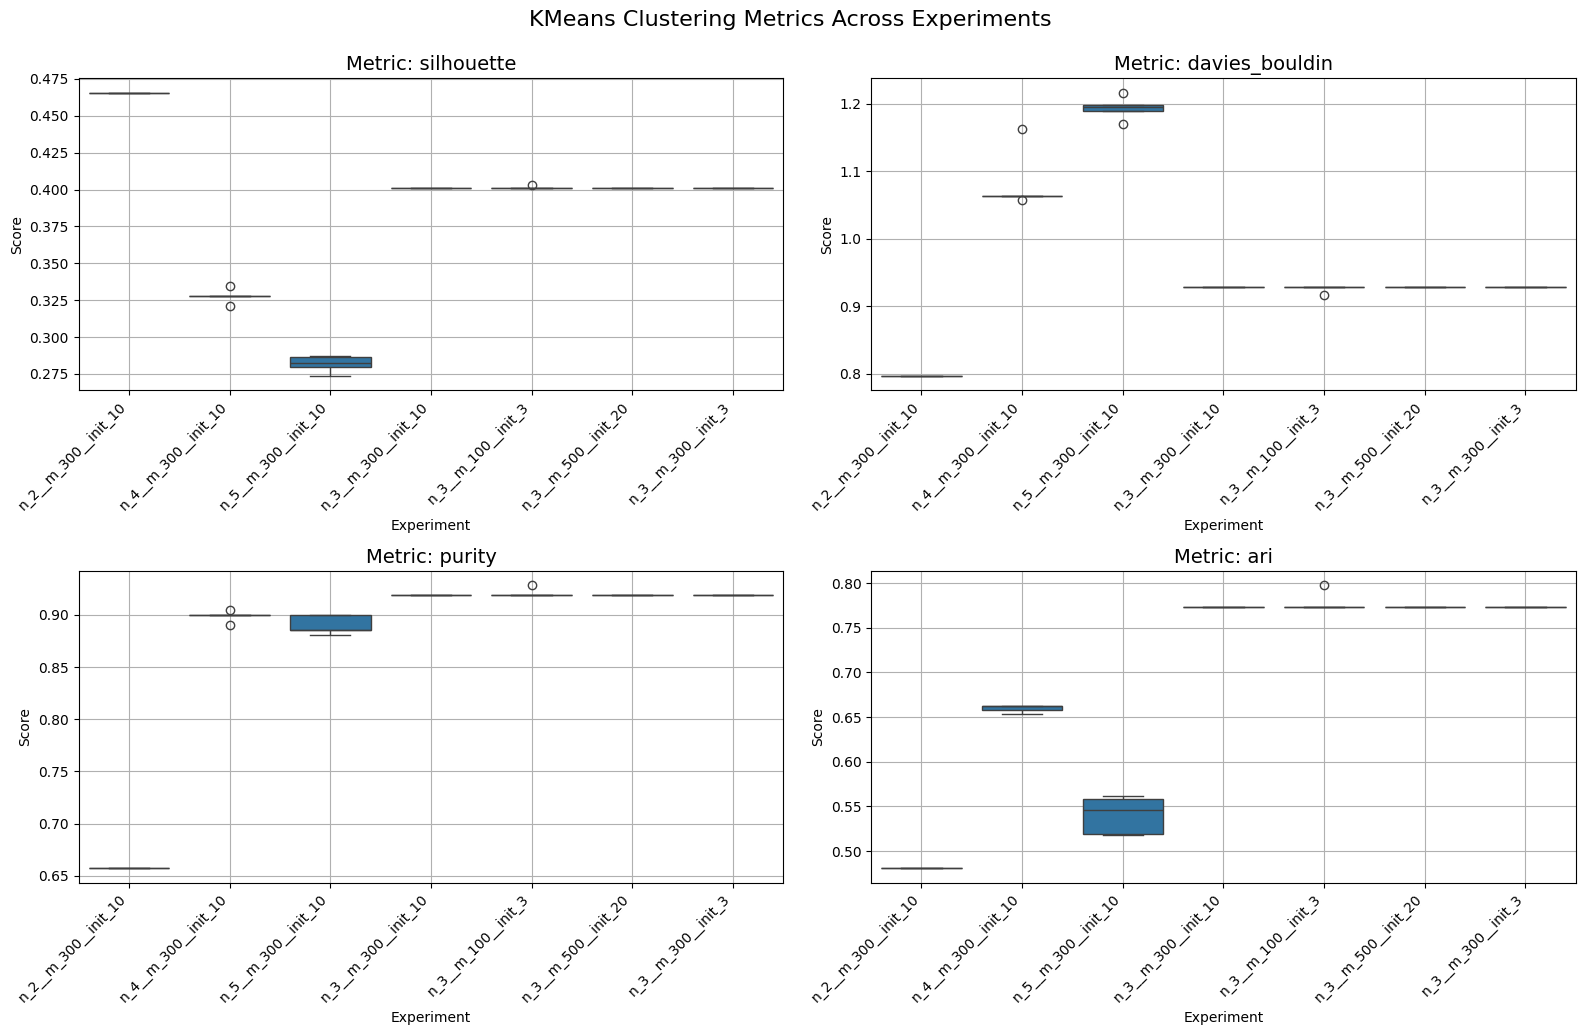

In [24]:
plot_results_kmeans(seeds_kmeans_results, supervised_metrics_names)

### 2.2.4 Wizualizacje

In [25]:
kmeans = KMeans(n_clusters=5, max_iter=300, n_init=10)
kmeans.fit(X_seeds)
seeds_y_kmeans_n5_m300_i10 = kmeans.predict(X_seeds)

kmeans = KMeans(n_clusters=3, max_iter=500, n_init=20)
kmeans.fit(X_seeds)
seeds_y_kmeans_n3_m500_i20 = kmeans.predict(X_seeds)

kmeans = KMeans(n_clusters=2, max_iter=300, n_init=10)
kmeans.fit(X_seeds)
seeds_y_kmeans_n2_m300_i10 = kmeans.predict(X_seeds)

Zbiór seeds jest o wiele prostszy do wizualizacji oraz zadania klasteryzacji niż glass.

Dla KMEANS 3 algorytm bardzo dobrze oddzielił klastry, co widać na wykresach.

Dla 2 klastrów algorytm również dobrze oddzielił klastry, ale nieco gorzej niż dla 3 klastrów, oczywiście ze względu na to, że ta wartośc jest zbyt mała.

dla 5 klastrów podział jest bardzo zły, ponieważ algorytm nie potrafił oddzielić klastra 1 i 2, co widać na wykresach.

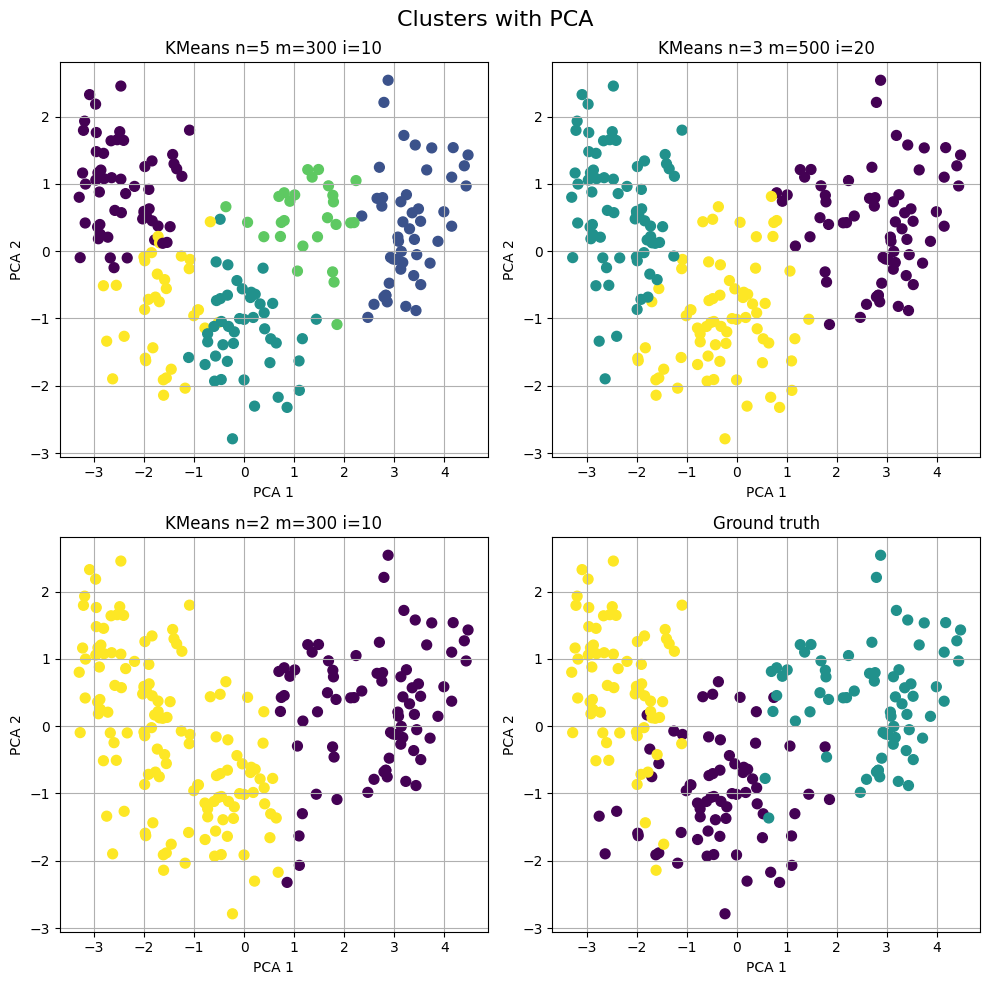

In [26]:
plot_clusters(X_seeds, y_seeds, [(seeds_y_kmeans_n5_m300_i10, 'KMeans n=5 m=300 i=10'),
                                 (seeds_y_kmeans_n3_m500_i20, 'KMeans n=3 m=500 i=20'),
                                 (seeds_y_kmeans_n2_m300_i10, 'KMeans n=2 m=300 i=10')],
              dim_red_method='PCA')

Algorytm TSNE umożliwił wizualizację danych w 2D, co pozwoliło na lepsze zrozumienie struktury klastrów, lecz wnioski są bardzo analogiczne jak do tych wyyżej.

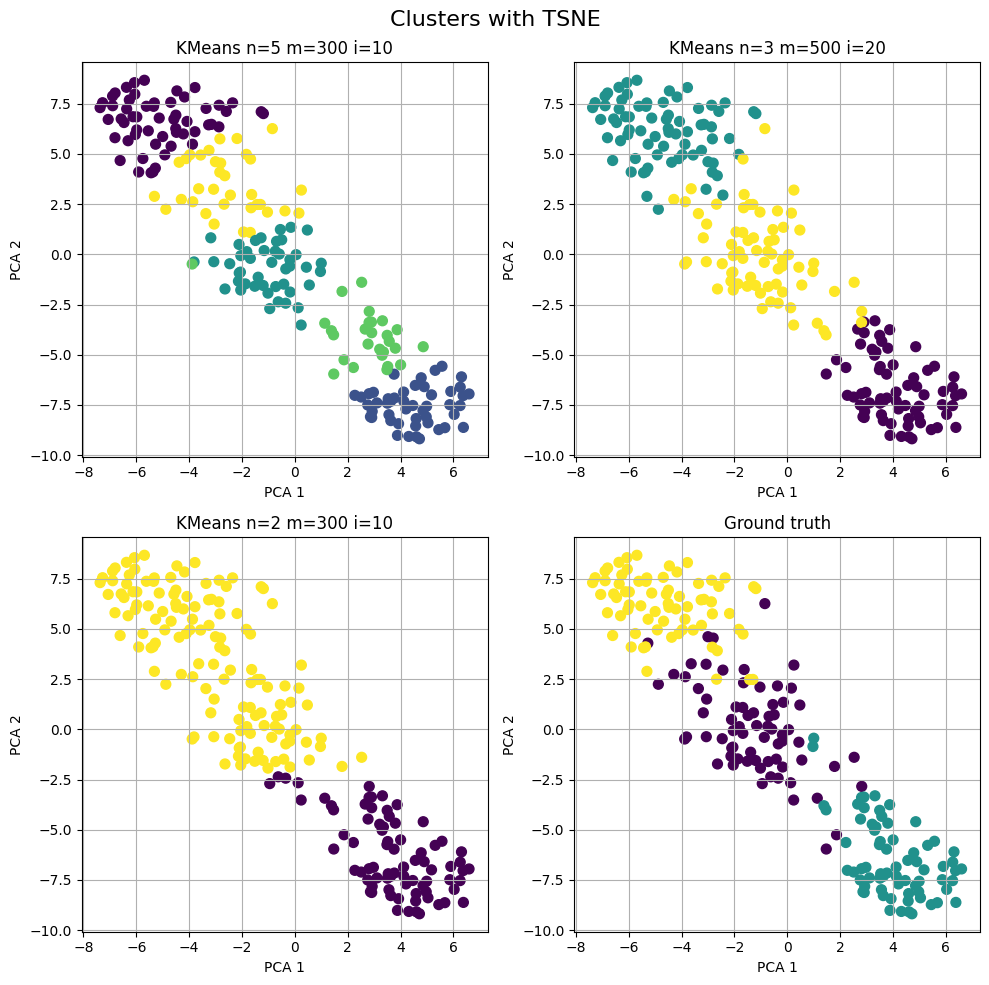

In [27]:
plot_clusters(X_seeds, y_seeds, [(seeds_y_kmeans_n5_m300_i10, 'KMeans n=5 m=300 i=10'),
                                 (seeds_y_kmeans_n3_m500_i20, 'KMeans n=3 m=500 i=20'),
                                 (seeds_y_kmeans_n2_m300_i10, 'KMeans n=2 m=300 i=10')],
              dim_red_method='TSNE')

# 3. Przebadanie algorytmu DBSCAN na zbiorach SEEDS i GLASS. Zbadanie jak zmieniają się wartości miar

## 3.1 GLASS

### 3.1.1 Wczytanie danych

In [28]:
glass_identification = fetch_ucirepo(id=42) 
  
X_glass = glass_identification.data.features 
y_glass = glass_identification.data.targets 
y_glass = y_glass.values.ravel()

scaler = StandardScaler()
X_glass = scaler.fit_transform(X_glass)

### 3.1.2 Uruchomienie k-means dla różnych hiperparametrów

Oryginalnie zbiór zawierał 25 różnych wartości hiperparametrów w celu utworzenia intyicji które z nich są najlepsze.

Następnie wybrano 7 najlepszych wartości na podstawie tego ile klastrów algorytm wykrył oraz jak dobrze oddzielił klastry.

In [29]:
glass_dbscan_hyperparams = [
    {'e_0.5_min_3_met_euc': {'eps': 0.5, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.3_min_3_met_euc': {'eps': 0.3, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.7_min_3_met_euc': {'eps': 0.7, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.9_min_3_met_euc': {'eps': 0.9, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.9_min_6_met_euc': {'eps': 0.9, 'min_samples': 6, 'metric': 'euclidean'}},
    {'e_0.7_min_3_met_man': {'eps': 0.7, 'min_samples': 3, 'metric': 'manhattan'}},
    {'e_0.9_min_3_met_man': {'eps': 0.9, 'min_samples': 3, 'metric': 'manhattan'}},
]


In [30]:
def train_dbscan(X, y, hyperparams_sets, metrics_names, metrics_functions):
    metrics = build_metrics(hyperparams_sets, metrics_names)
    
    for experiment in hyperparams_sets:
        experiment_name = list(experiment.keys())[0]
        hyperparams = experiment[experiment_name]

        dbscan = DBSCAN(eps=hyperparams['eps'], min_samples=hyperparams['min_samples'], metric=hyperparams['metric'])
        dbscan.fit(X)
        y_dbscan = dbscan.labels_

        mask = y_dbscan != -1
        X_valid = X[mask]
        y_valid = y_dbscan[mask]

        for metric_name, metric_function in zip(metrics_names, metrics_functions):
            if metric_name in ['purity', 'ari']:
                score = metric_function(y, y_dbscan)
            else:
                if len(set(y_valid)) < 2:
                    continue 
                score = metric_function(X_valid, y_valid)

            metrics[experiment_name][metric_name].append(score)

    return metrics


In [31]:
glass_dbscan_results = train_dbscan(X_glass, y_glass, glass_dbscan_hyperparams, supervised_metrics_names, supervised_metrics_functions)

### 3.1.3 Obliczenie metryk jakości

In [32]:
def plot_results_dbscan(results, metrics_names):
    data = []
    for experiment_name, metrics_dict in results.items():
        for metric_name, values in metrics_dict.items():
            for value in values:
                data.append({
                    'experiment': experiment_name,
                    'metric': metric_name,
                    'value': float(value)
                })

    df_metrics = pd.DataFrame(data)

    df_means = df_metrics.groupby(['experiment', 'metric'])['value'].mean().reset_index()

    plt.figure(figsize=(16, 10))
    for i, metric_name in enumerate(metrics_names):
        plt.subplot(2, 2, i + 1)
        metric_data = df_means[df_means['metric'] == metric_name]
        bars = plt.bar(metric_data['experiment'], metric_data['value'], color='skyblue')
        plt.title(f'Metric: {metric_name}', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Experiment')
        plt.ylabel('Score')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.suptitle('DBSCAN Clustering Metrics', fontsize=16, y=1.03)
    plt.show()

Ze względu na deterministyczność algorytmu DBSCAN, przeprowadzono jeden eksperyment z różnymi wartościami hiperparametrów. Zdecydowano się na 4 różne wartości eps oraz 2 różne wartości min_samples oraz odległości manhatan oraz euklidesową.

#### Najlepsze wyniki:
- **Zestaw `e_0.9_min_6_met_euc`** osiągnął najlepsze wyniki:
  - **Silhouette**:  średnia umiejętność separacji klas.
  - **Davies-Bouldin Index**:  średnia wartość.
  - **Purity**: bardzo wysoka zgodność klastrów z prawdziwymi etykietami.
  - **ARI**: najlepsze odwzorowanie prawdziwego podziału klas.

#### Najsłabsze wyniki:
- **Zestaw `e_0.9_min_3_met_man`** wypadł najsłabiej:
  - **Silhouette**: najniższe, słaba separacja klastrów.
  - **Davies-Bouldin**: klastry nakładają się i są rozproszone, najwyższe wartości.
  - **Purity**: najniższa zgodność z rzeczywistymi etykietami.
  - **ARI**: najgorsza zgodność z rzeczywistymi etykietami.

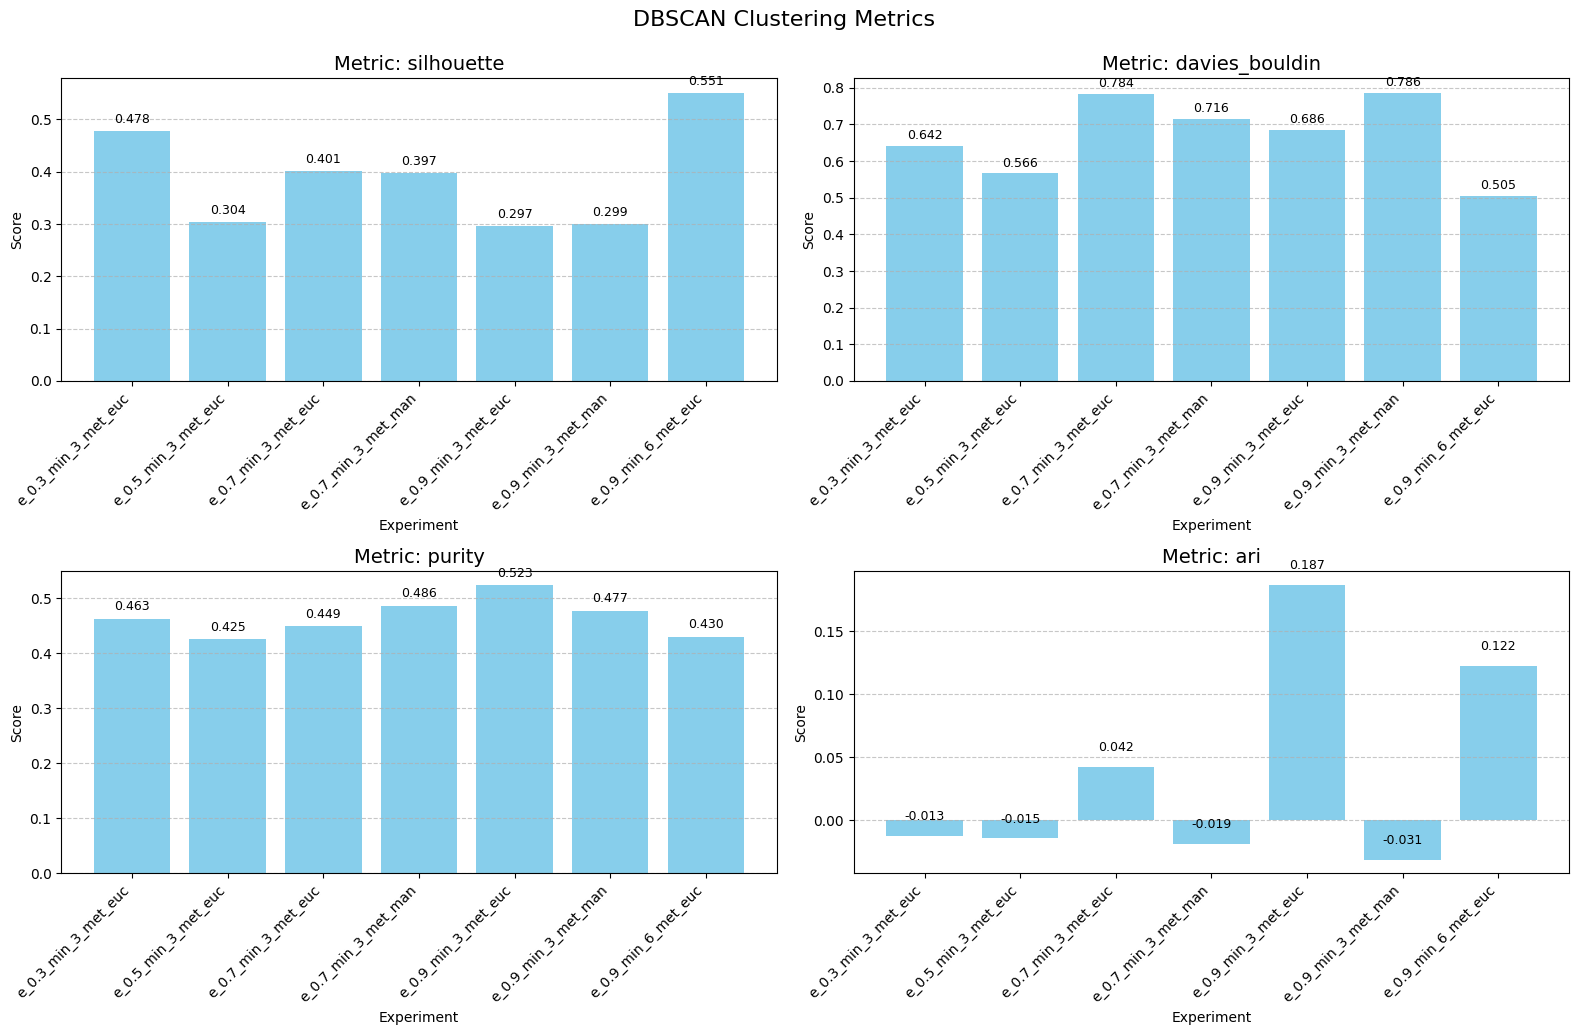

In [33]:
plot_results_dbscan(glass_dbscan_results, supervised_metrics_names)

### 3.1.4 Wizualizacje

In [34]:
dbscan = DBSCAN(eps=0.9, min_samples=3, metric='euclidean')
dbscan.fit(X_glass)
y_dbscan_eps_0_9_min_3_met_euc = dbscan.labels_

dbscan = DBSCAN(eps=0.9, min_samples=6, metric='euclidean')
dbscan.fit(X_glass)
y_dbscan_eps_0_9_min_6_met_euc = dbscan.labels_

dbscan = DBSCAN(eps=0.5, min_samples=3, metric='euclidean')
dbscan.fit(X_glass)
y_dbscan_eps_0_5_min_3_met_euc = dbscan.labels_

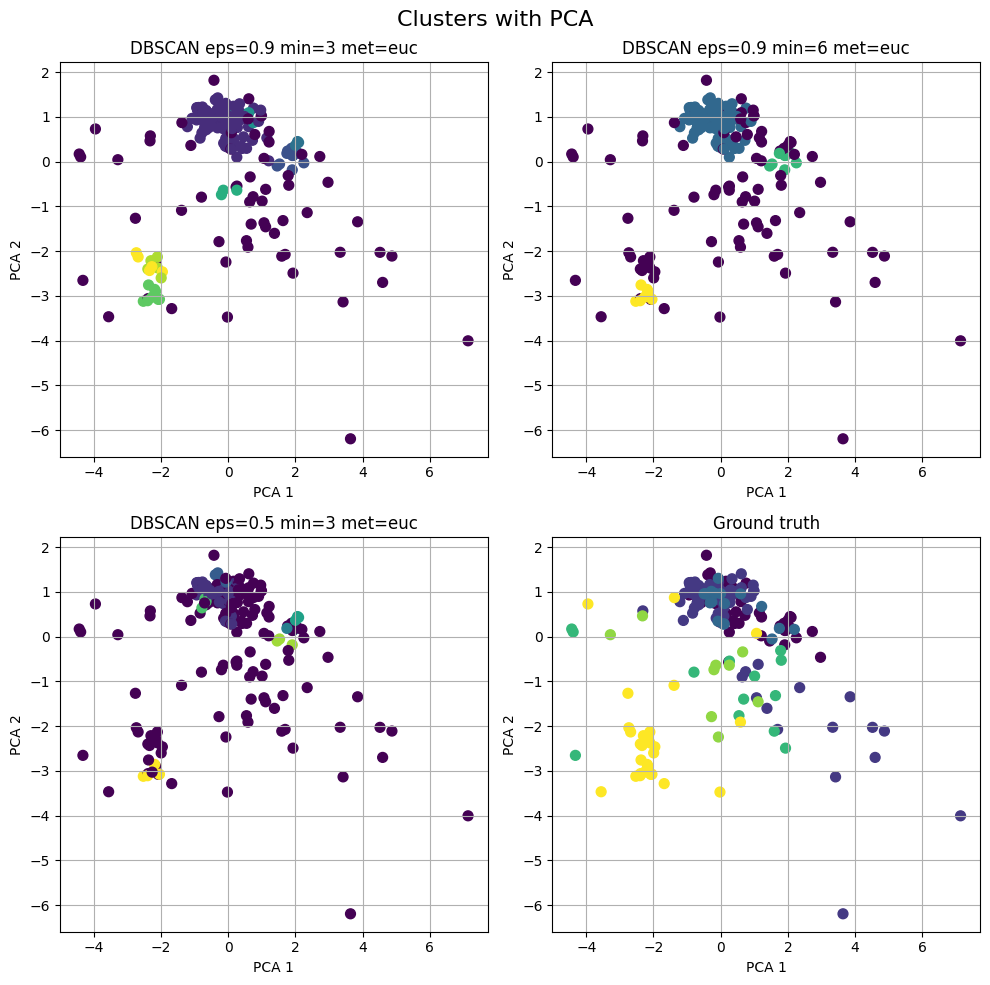

In [35]:
plot_clusters(X_glass, y_glass, [(y_dbscan_eps_0_9_min_3_met_euc, 'DBSCAN eps=0.9 min=3 met=euc'),
                                 (y_dbscan_eps_0_9_min_6_met_euc, 'DBSCAN eps=0.9 min=6 met=euc'),
                                 (y_dbscan_eps_0_5_min_3_met_euc, 'DBSCAN eps=0.5 min=3 met=euc')],
              dim_red_method='PCA')

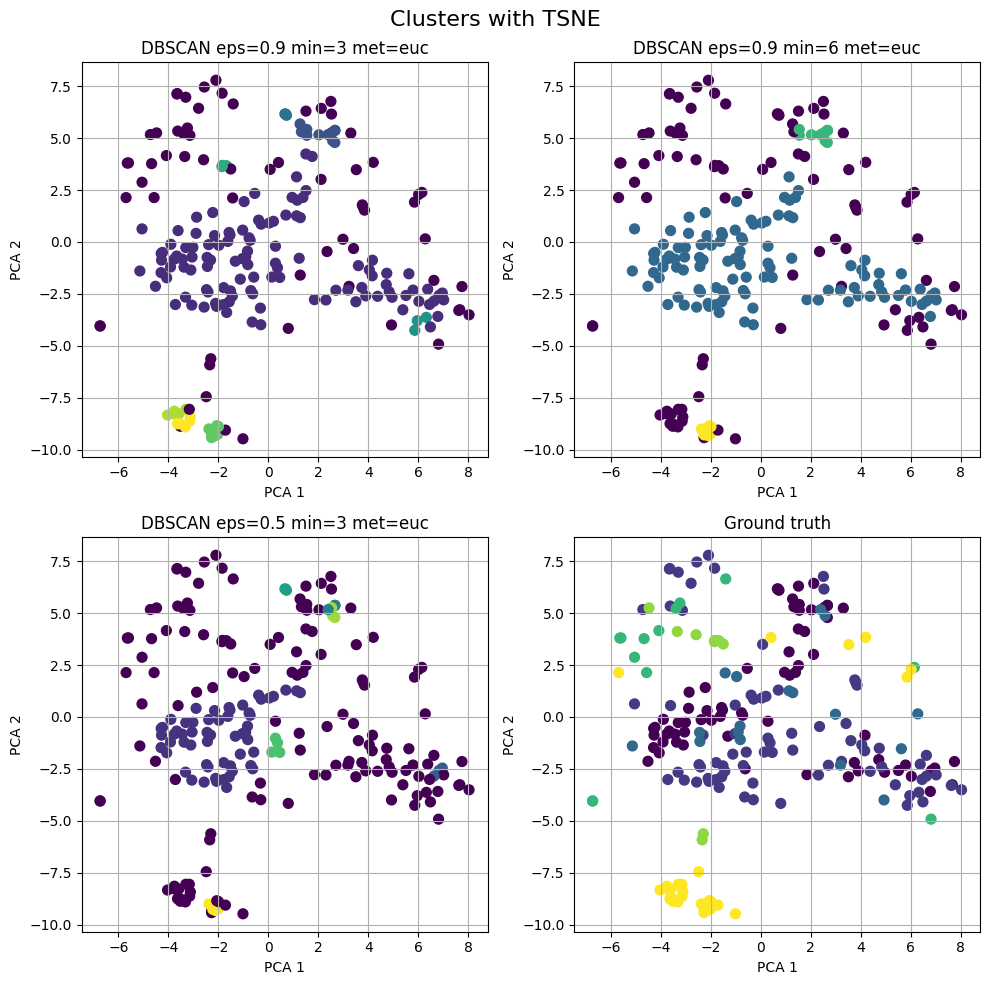

In [36]:
plot_clusters(X_glass, y_glass, [(y_dbscan_eps_0_9_min_3_met_euc, 'DBSCAN eps=0.9 min=3 met=euc'),
                                 (y_dbscan_eps_0_9_min_6_met_euc, 'DBSCAN eps=0.9 min=6 met=euc'),
                                 (y_dbscan_eps_0_5_min_3_met_euc, 'DBSCAN eps=0.5 min=3 met=euc')],
              dim_red_method='TSNE')

## 3.2 SEEDS

### 3.2.1 Wczytanie danych

In [37]:
seed_data = pd.read_csv('Seed_Data.csv')
X_seeds = seed_data.drop(columns=['target'])
y_seeds = seed_data['target']

scaler = StandardScaler()
X_seeds = scaler.fit_transform(X_seeds)

### 3.2.2 Uruchomienie k-means dla różnych hiperparametrów

In [38]:
seeds_dbscan_hyperparams = [
    {'e_0.5_min_3_met_euc': {'eps': 0.5, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.3_min_3_met_euc': {'eps': 0.3, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.7_min_3_met_euc': {'eps': 0.7, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.9_min_3_met_euc': {'eps': 0.9, 'min_samples': 3, 'metric': 'euclidean'}},
    {'e_0.9_min_6_met_euc': {'eps': 0.9, 'min_samples': 6, 'metric': 'euclidean'}},
    {'e_0.7_min_3_met_man': {'eps': 0.7, 'min_samples': 3, 'metric': 'manhattan'}},
    {'e_0.9_min_3_met_man': {'eps': 0.9, 'min_samples': 3, 'metric': 'manhattan'}},
]

In [39]:
seeds_dbscan_results = train_dbscan(X_seeds, y_seeds, seeds_dbscan_hyperparams, supervised_metrics_names, supervised_metrics_functions)

### 3.2.3 Obliczenie metryk jakości

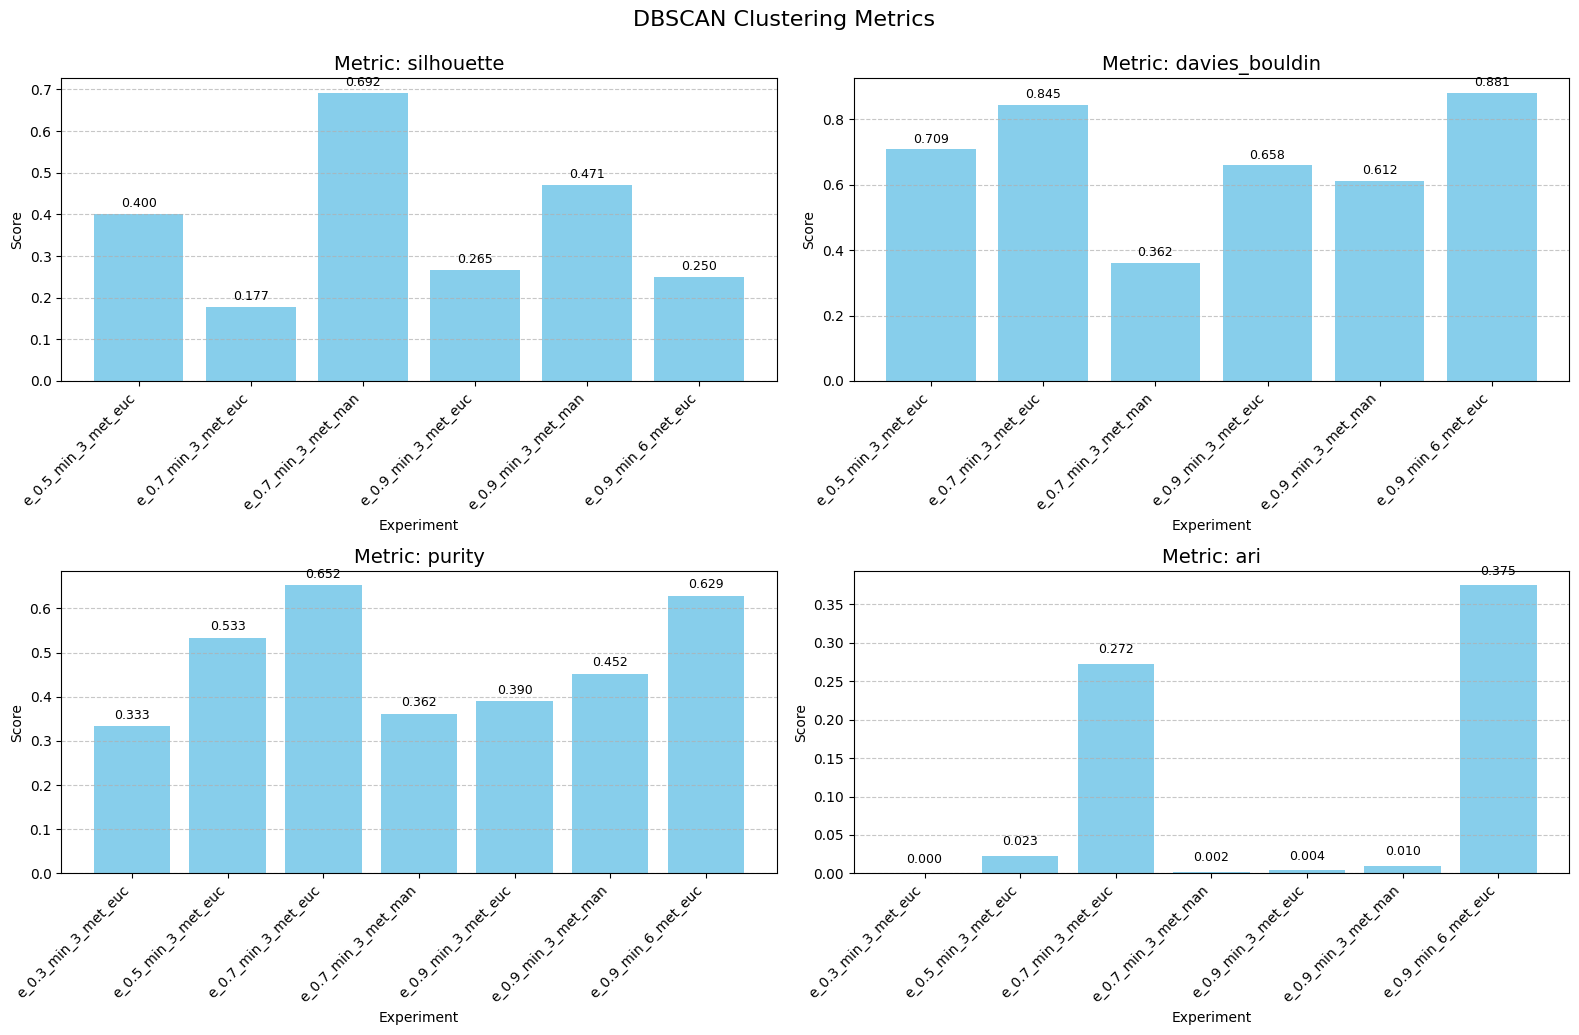

In [40]:
plot_results_dbscan(seeds_dbscan_results, supervised_metrics_names)

### 3.2.4 Wizualizacje

In [41]:
dbscan = DBSCAN(eps=0.7, min_samples=3, metric='euclidean')
dbscan.fit(X_seeds)
y_seeds_dbscan_eps_0_7_min_3_met_euc = dbscan.labels_

dbscan = DBSCAN(eps=0.9, min_samples=6, metric='euclidean')
dbscan.fit(X_seeds)
y_seeds_dbscan_eps_0_9_min_6_met_euc = dbscan.labels_

dbscan = DBSCAN(eps=0.9, min_samples=3, metric='manhattan')
dbscan.fit(X_seeds)
y_seeds_dbscan_eps_0_9_min_3_met_man = dbscan.labels_

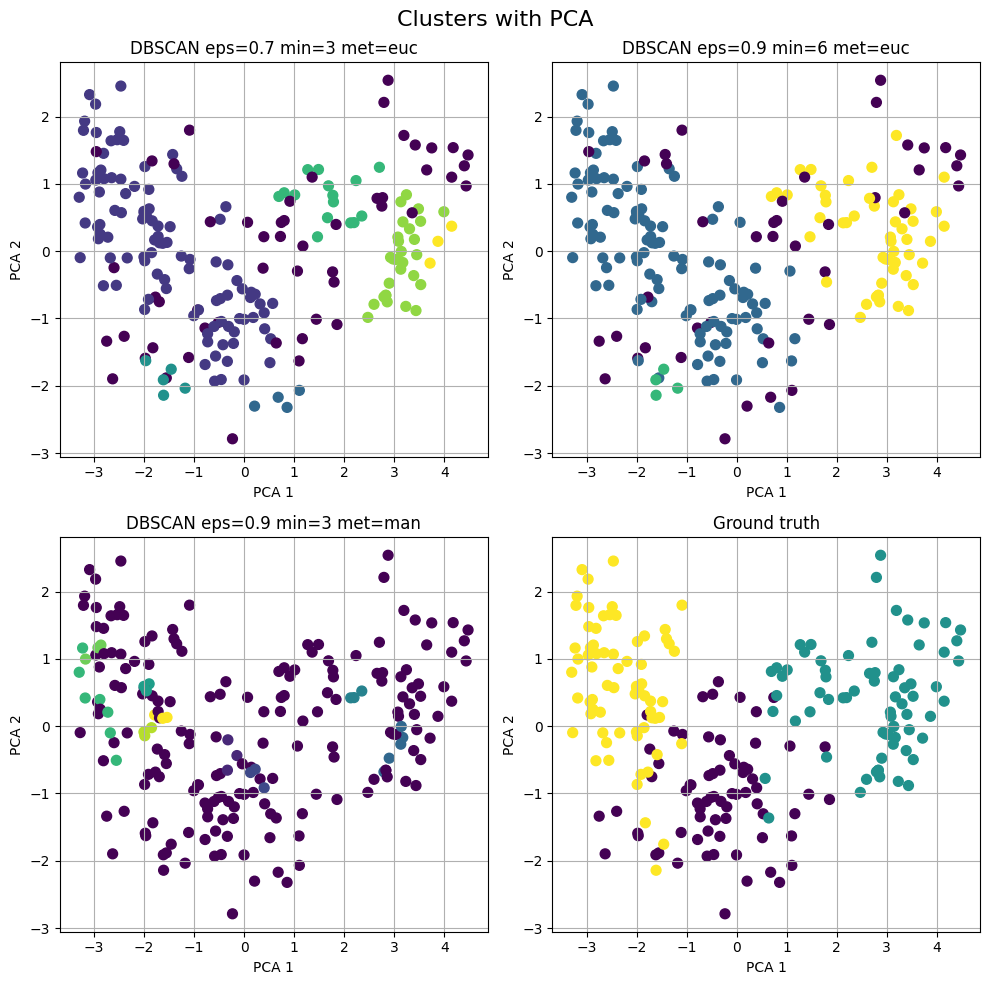

In [42]:
plot_clusters(X_seeds, y_seeds, [(y_seeds_dbscan_eps_0_7_min_3_met_euc, 'DBSCAN eps=0.7 min=3 met=euc'),
                                 (y_seeds_dbscan_eps_0_9_min_6_met_euc, 'DBSCAN eps=0.9 min=6 met=euc'),
                                 (y_seeds_dbscan_eps_0_9_min_3_met_man, 'DBSCAN eps=0.9 min=3 met=man')],
              dim_red_method='PCA')

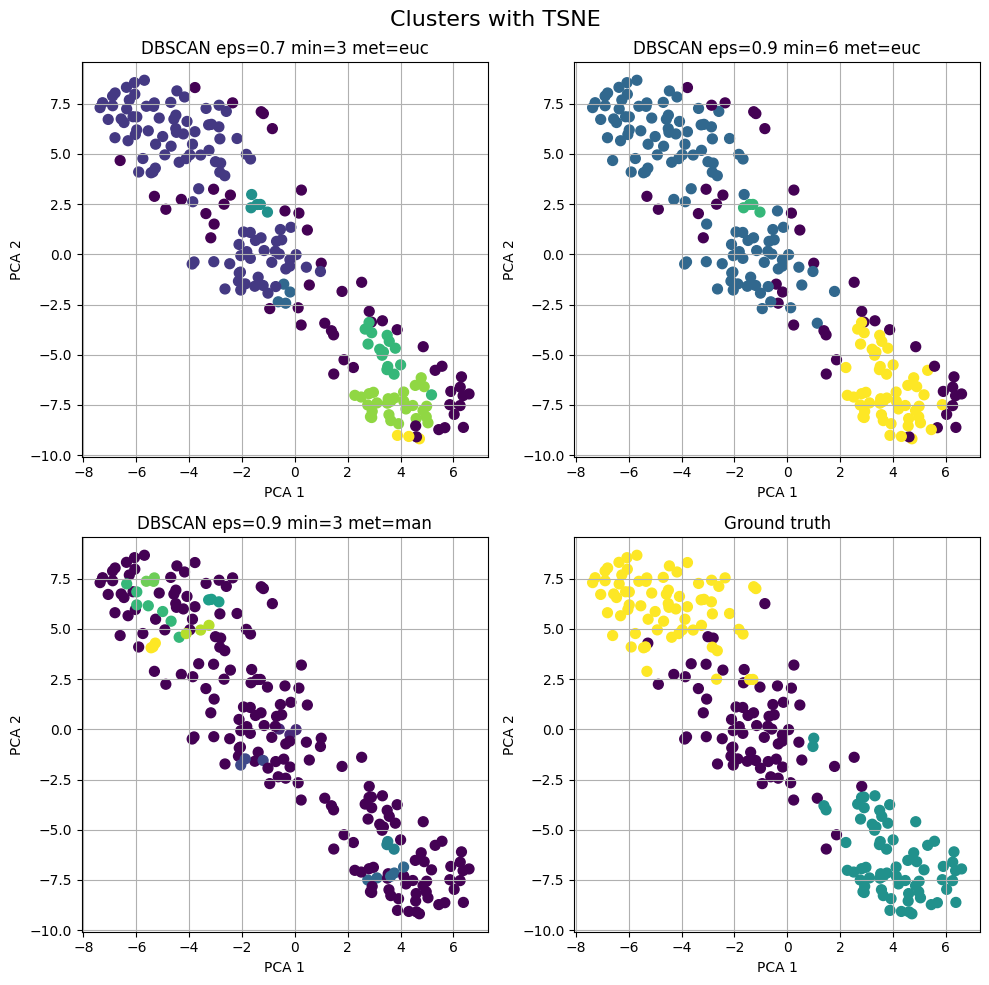

In [43]:
plot_clusters(X_seeds, y_seeds, [(y_seeds_dbscan_eps_0_7_min_3_met_euc, 'DBSCAN eps=0.7 min=3 met=euc'),
                                 (y_seeds_dbscan_eps_0_9_min_6_met_euc, 'DBSCAN eps=0.9 min=6 met=euc'),
                                 (y_seeds_dbscan_eps_0_9_min_3_met_man, 'DBSCAN eps=0.9 min=3 met=man')],
              dim_red_method='TSNE')

# 4. Analiza wyników

## 4.1 Porównanie działania algorytmów k-means i DBSCAN

### 4.1.1 Porównanie wyników dla zbioru SEEDS

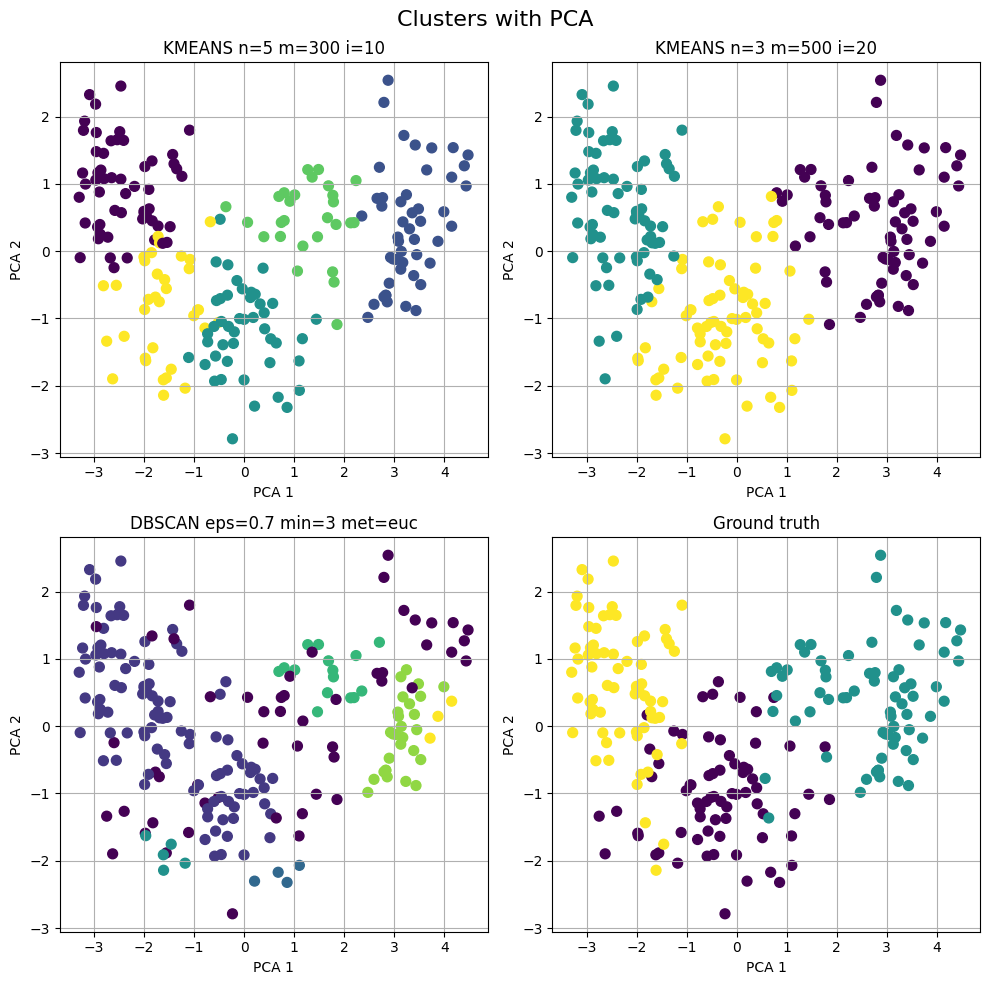

In [44]:
plot_clusters(X_seeds, y_seeds, [(seeds_y_kmeans_n5_m300_i10, 'KMEANS n=5 m=300 i=10'),
                                 (seeds_y_kmeans_n3_m500_i20, 'KMEANS n=3 m=500 i=20'),
                                 (y_seeds_dbscan_eps_0_7_min_3_met_euc, 'DBSCAN eps=0.7 min=3 met=euc')],
              dim_red_method='PCA')

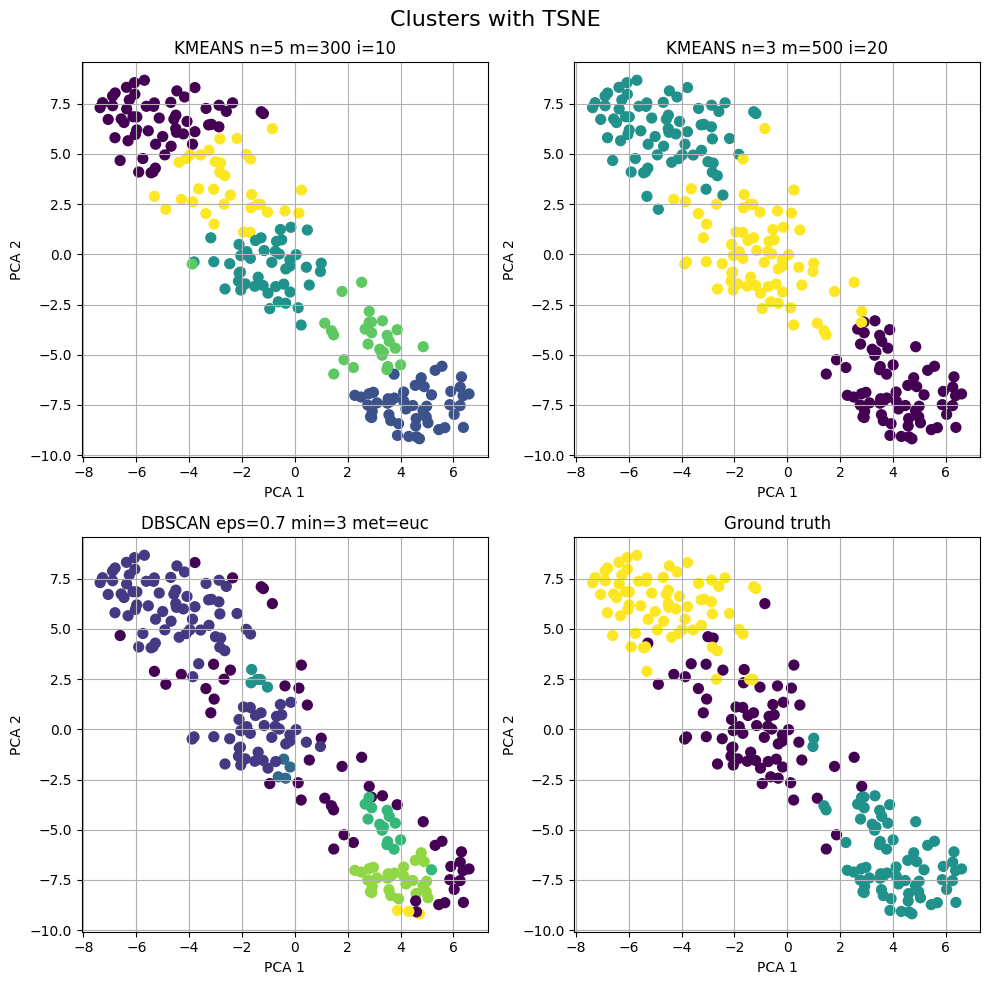

In [45]:
plot_clusters(X_seeds, y_seeds, [(seeds_y_kmeans_n5_m300_i10, 'KMEANS n=5 m=300 i=10'),
                                 (seeds_y_kmeans_n3_m500_i20, 'KMEANS n=3 m=500 i=20'),
                                 (y_seeds_dbscan_eps_0_7_min_3_met_euc, 'DBSCAN eps=0.7 min=3 met=euc')],
              dim_red_method='TSNE')

### 4.1.2 Porównanie wyników dla zbioru GLASS

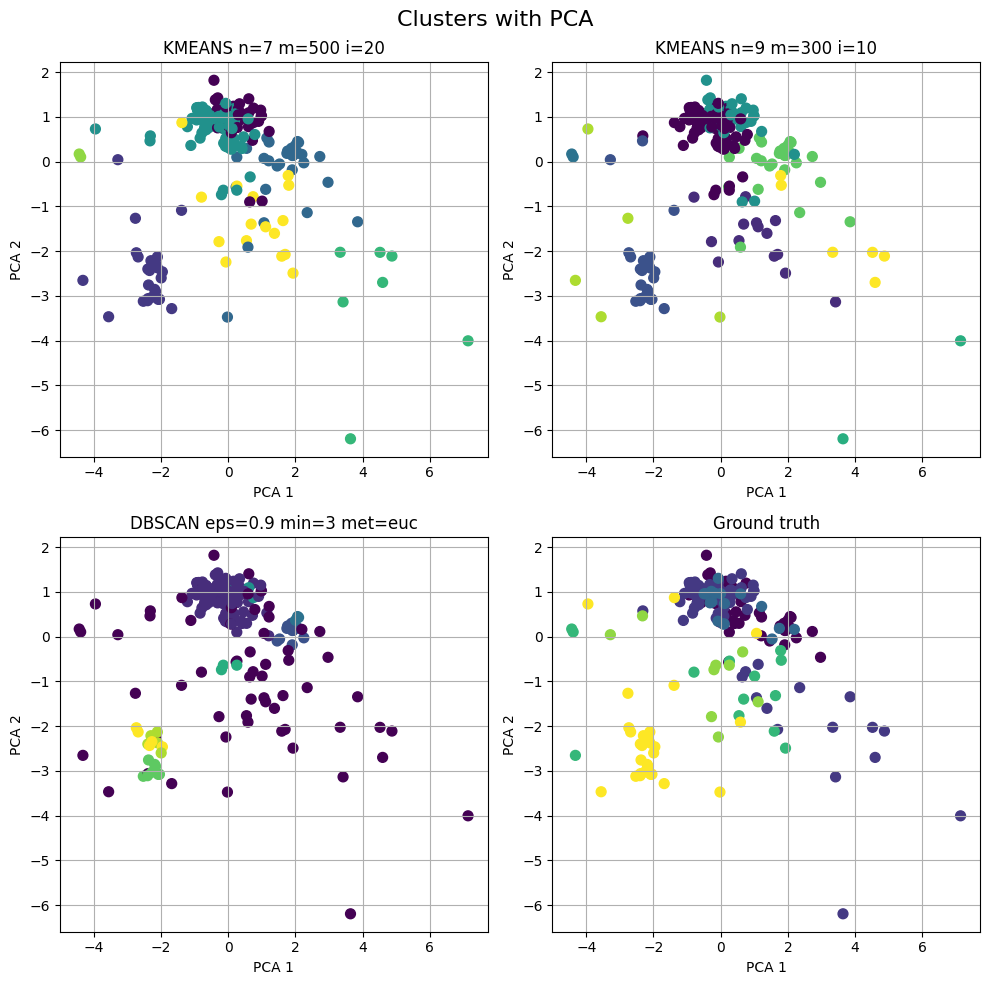

In [46]:
plot_clusters(X_glass, y_glass, [(glass_y_kmeans_n7_m500_i20, 'KMEANS n=7 m=500 i=20'),
                                 (glass_y_kmeans_n9_m300_i10, 'KMEANS n=9 m=300 i=10'),
                                 (y_dbscan_eps_0_9_min_3_met_euc, 'DBSCAN eps=0.9 min=3 met=euc')],
              dim_red_method='PCA')

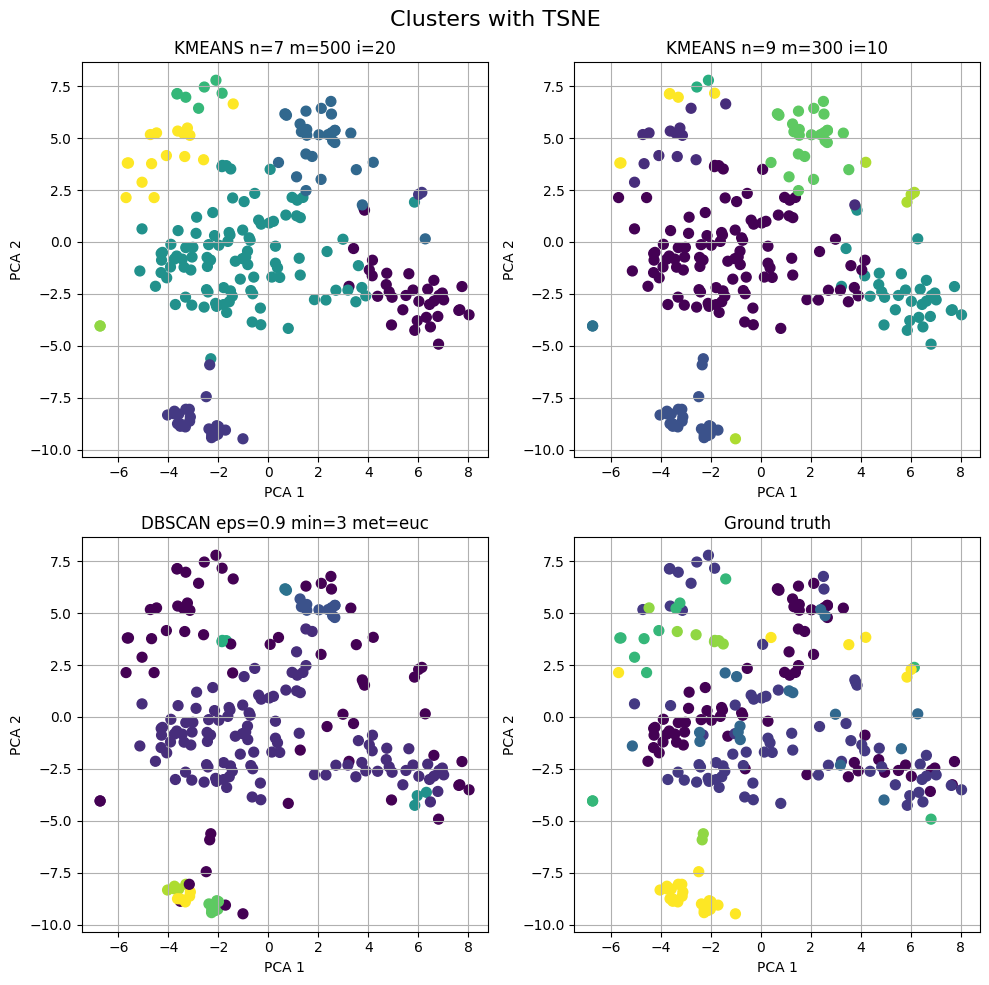

In [47]:
plot_clusters(X_glass, y_glass, [(glass_y_kmeans_n7_m500_i20, 'KMEANS n=7 m=500 i=20'),
                                 (glass_y_kmeans_n9_m300_i10, 'KMEANS n=9 m=300 i=10'),
                                 (y_dbscan_eps_0_9_min_3_met_euc, 'DBSCAN eps=0.9 min=3 met=euc')],
              dim_red_method='TSNE')

## 4.2 Porównanie użytych miar jakości grupowania.

### 4.2.1 Porównanie miar jakości dla zbioru SEEDS

#### Najlepsze wyniki:
- **Silhouette** osiągnął najwyższą wartość (0.692) dla `e_0.7_min_3_met_man`.
- Najniższy **Davies-Bouldin Index** (0.362), również dla `e_0.7_min_3_met_man`.
- Najwyższe **Purity** (0.921) i **ARI** (0.778) uzyskano dla `n_3__m_100__init_3`.

#### Najsłabsze wyniki:
- Najniższe wartości **Purity** (0.333) i **ARI** (0.000) wystąpiły w `e_0.3_min_3_met_euc`, co oznacza niemal całkowity brak zgodności klastrów z klasami referencyjnymi.
- Konfiguracje DBSCAN, mimo wysokich wyników w metrykach wewnętrznych (np. `e_0.7_min_3_met_man`), często uzyskiwały niskie wyniki ARI i Purity, co sugeruje, że wykrywały struktury inne niż rzeczywiste klasy.

#### Wnioski:
- **KMeans** w konfiguracjach z 3 klastrami (`n_3__m_100__init_3`, `n_3__m_300__init_10`, itd.) regularnie osiągał bardzo dobre wyniki w metrykach z etykietami (Purity, ARI).
- **DBSCAN**, przy odpowiednich parametrach (`e_0.7_min_3_met_man`), dobrze oddzielał klastry w przestrzeni danych (Silhouette, Davies-Bouldin), ale nie zawsze odpowiadały one rzeczywistym klasom.

| Eksperyment               | Silhouette | Davies-Bouldin | Purity | ARI   |
|--------------------------|------------|----------------|--------|-------|
| n_2__m_300__init_10      | 0.466      | 0.797          | 0.657  | 0.481 |
| n_4__m_300__init_10      | 0.328      | 1.081          | **0.899**  | **0.660** |
| n_5__m_300__init_10      | 0.282      | **1.194**      | 0.890  | 0.540 |
| n_3__m_300__init_10      | 0.401      | 0.928          | **0.919**  | **0.773** |
| n_3__m_100__init_3       | 0.401      | 0.926          | **0.921**  | **0.778** |
| n_3__m_500__init_20      | 0.401      | 0.928          | **0.919**  | **0.773** |
| n_3__m_300__init_3       | 0.401      | 0.928          | **0.919**  | **0.773** |
| e_0.5_min_3_met_euc      | 0.400      | **0.709**      | 0.533  | 0.023 |
| e_0.3_min_3_met_euc      | —          | —              | 0.333  | 0.000 |
| e_0.7_min_3_met_euc      | 0.177      | 0.845          | 0.652  | 0.272 |
| e_0.9_min_3_met_euc      | 0.265      | 0.658          | 0.390  | 0.004 |
| e_0.9_min_6_met_euc      | 0.250      | 0.881          | 0.629  | 0.375 |
| e_0.7_min_3_met_man      | **0.692**  | **0.362**      | 0.362  | 0.002 |
| e_0.9_min_3_met_man      | **0.471**  | 0.612          | 0.452  | 0.010 |


### 4.2.2 Porównanie miar jakości dla zbioru GLASS

#### Najlepsze wyniki:
- Najwyższy wynik **Silhouette** (0.551) oraz najniższy **Davies-Bouldin Index** (0.505) osiągnięto dla konfiguracji `e_0.9_min_6_met_euc`.
- Najwyższą wartość **Purity** (0.591) uzyskano w eksperymencie `n_9__m_300__init_10` (KMeans), co oznacza, że klastry dobrze odpowiadały klasom referencyjnym.
- Najlepszy wynik **ARI** (0.230) osiągnięto również dla `n_5__m_300__init_10`, wskazując na wysoką zgodność struktury klastrów z prawdziwym podziałem klas.

#### Najsłabsze wyniki:
- Najniższe wyniki zarówno dla **Purity** (0.425), jak i **ARI** (-0.015) odnotowano dla `e_0.5_min_3_met_euc` (DBSCAN), co oznacza słabą zgodność z klasami referencyjnymi i prawdopodobnie zbyt agresywne wycinanie punktów jako szum.
- Również w eksperymentach `e_0.3_min_3_met_euc` i `e_0.9_min_3_met_man` wartości ARI były bliskie zera lub ujemne, co świadczy o przypadkowej lub nietrafionej segmentacji danych.

#### Wnioski:
- Algorytm KMeans, zwłaszcza w konfiguracjach z większą liczbą klastrów (np. `n_5__m_300__init_10`, `n_9__m_300__init_10`), osiągał lepsze wyniki w metrykach wymagających etykiet (Purity, ARI).
- Z kolei DBSCAN, w odpowiednio dobranych parametrach (`e_0.9_min_6_met_euc`), pozwalał uzyskać bardzo dobre wyniki w metrykach wewnętrznych (Silhouette, Davies-Bouldin), ale nie zawsze przekładało się to na wysoką zgodność z klasami.
- Dobór metryki do oceny powinien zależeć od celu analizy – jeśli nie dysponujemy etykietami, należy opierać się na Silhouette i Davies-Bouldin, natomiast jeśli celem jest odwzorowanie znanych klas, lepiej kierować się ARI i Purity.


| Eksperyment               | Silhouette | Davies-Bouldin | Purity | ARI   |
|--------------------------|------------|----------------|--------|-------|
| e_0.5_min_3_met_euc      | 0.304      | **0.566**      | 0.425  | -0.015 |
| e_0.3_min_3_met_euc      | **0.478**  | 0.642          | 0.463  | -0.013 |
| e_0.7_min_3_met_euc      | 0.401      | 0.784          | 0.449  | 0.042 |
| e_0.9_min_3_met_euc      | 0.297      | 0.686          | **0.523**  | **0.187** |
| e_0.9_min_6_met_euc      | **0.551**  | **0.505**      | 0.430  | **0.122** |
| e_0.7_min_3_met_man      | 0.397      | 0.716          | 0.486  | -0.019 |
| e_0.9_min_3_met_man      | 0.299      | 0.786          | 0.477  | -0.031 |
| n_3__m_300__init_10      | 0.367      | 1.381          | 0.479  | **0.200** |
| n_5__m_300__init_10      | 0.341      | 1.078          | **0.554**  | **0.230** |
| n_9__m_300__init_10      | 0.357      | 1.028          | **0.591**  | 0.197 |
| n_7__m_300__init_10      | 0.344      | 1.028          | 0.580  | 0.190 |
| n_7__m_100__init_3       | 0.336      | **0.974**      | 0.564  | 0.174 |
| n_7__m_500__init_20      | 0.342      | 1.024          | 0.582  | 0.188 |
| n_7__m_300__init_3       | 0.340      | 1.005          | 0.573  | 0.191 |
